In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import seaborn_image as isns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

import scienceplots
# plt.style.use('science')
sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")

In [105]:
def preprocess_plot(df, name, plotting = True):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        # _, p = stats.ttest_ind(df[(df['Behaviour_6hFD'] == 'Pre')][column].dropna(),
        #                             df[df['Behaviour_6hFD'] == 'Post'][column].dropna(),
        #                             equal_var = True)
        else:
            param_df = df
        
        try:
            _, p1 = stats.mannwhitneyu(param_df[(param_df.Behaviour_6hFD == 'Pre')][column].dropna(),
                                        param_df[(param_df.Behaviour_6hFD == 'Agg+')][column].dropna())
            
            print(column, 'noFD_Agg+', p1)

            _, p2 = stats.mannwhitneyu(param_df[(param_df.Behaviour_6hFD == 'Agg+')][column].dropna(),
                                        param_df[(param_df.Behaviour_6hFD == 'Agg-')][column].dropna())
            
            print(column , 'Agg+_Agg-', p2)

            _, p3 = stats.mannwhitneyu(param_df[(param_df.Behaviour_6hFD == 'Agg+')][column].dropna(),
                                        param_df[(param_df.Behaviour_6hFD == 'npy_antag')][column].dropna())
            
            print(column , 'Agg+_npy-antag', p3)

        except ValueError:
            
            continue

        if plotting:
            try:
                
                fig,ax = plt.subplots(figsize = (3,3))
            
                sns.swarmplot(x='Behaviour_6hFD', y =column, data= param_df, palette = ['darkgray', '#F97306'], alpha = 1, size = 3)
                sns.boxplot(x='Behaviour_6hFD', y =column, data= param_df, palette = ['darkgray', '#F97306'], boxprops=dict(alpha=0.7), width = 0.5)
                sns.despine()
                plt.title(column, pad = 20)
                plt.xticks(rotation = 90)
                plt.savefig(f'output_figures/{name}_{column}.png',dpi = 300, bbox_inches = 'tight')
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:3, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# epnys analysis

In [93]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD =='Agg+','Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)

cat = df.Behaviour_6hFD.unique()

gal = df[df.Gal_positive == 'yes']
no_gal = df[df.Gal_positive == 'no']
ephys = df[df.Gal_positive.isin(['Unknown', 'no'])]
ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[df.Behaviour_6hFD.isin(cat)]])
sample_num= int(no_gal.shape[0]/4)
ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 859)]).reset_index(drop = True)


ephys.to_csv('sampled_ephys_data.csv')

In [94]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_10', 'npy_100',
       'agrp_100'], dtype=object)

## all properties

Cm(pF) noFD_Agg+ 0.13451684745243198
Firing_freq_(Hz)_I0 noFD_Agg+ 0.009987674731723671
Firing_freq_(Hz)_I0 Agg+_Agg- 0.004486801649781591
Firing_freq_(Hz)_I0 Agg+_npy-antag 0.0021884832654053485


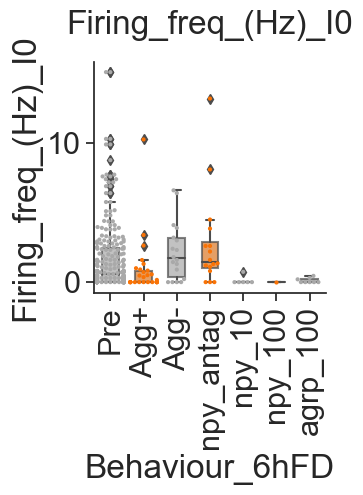

Instant_freq_(Hz) noFD_Agg+ 0.006874220766097158
Instant_freq_(Hz) Agg+_Agg- 0.00951248466124584
Instant_freq_(Hz) Agg+_npy-antag 0.003268762722197171


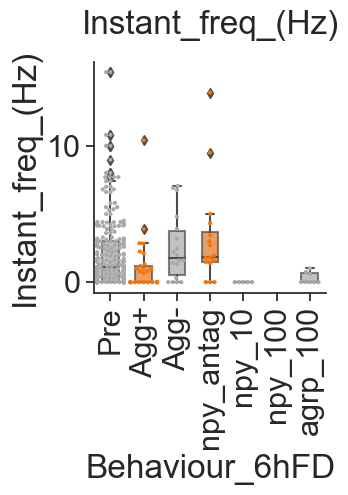

isi_(ms) noFD_Agg+ 0.6907649348388157
isi_(ms) Agg+_Agg- 0.02907155995483803
isi_(ms) Agg+_npy-antag 0.018596672842396383


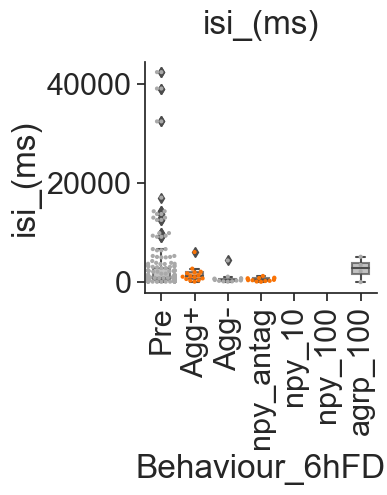

CaT noFD_Agg+ 0.1712124050690772
CaT Agg+_Agg- 0.04037084851706265
CaT Agg+_npy-antag 0.12548666206898038


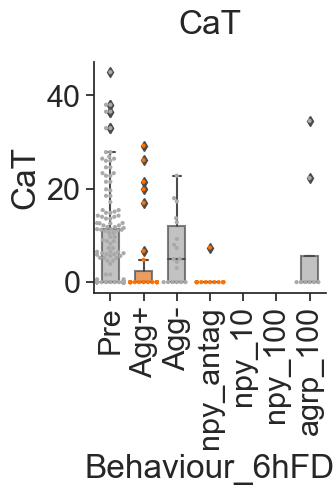

Ih_at_-120mV noFD_Agg+ 0.009430439383629686
Ih_at_-120mV Agg+_Agg- 0.0011649244097342523
Ih_at_-120mV Agg+_npy-antag 0.4289564809661256


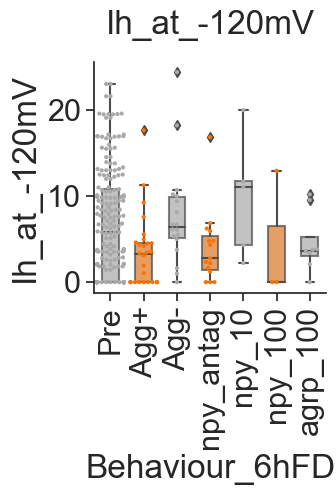

AP_ampl noFD_Agg+ 0.6356668265471896
AP_ampl Agg+_Agg- 0.8004638591288532
AP_ampl Agg+_npy-antag 0.4815967507356862


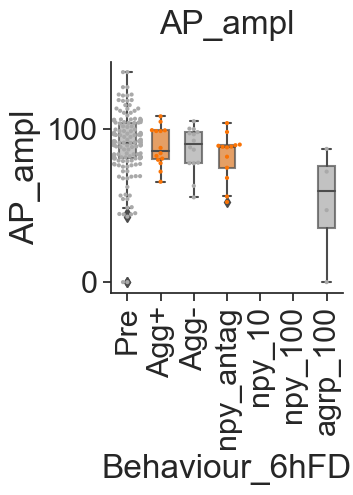

AP_halfwidth noFD_Agg+ 0.7953775043445768
AP_halfwidth Agg+_Agg- 0.11773229632209697
AP_halfwidth Agg+_npy-antag 0.12619643972725164


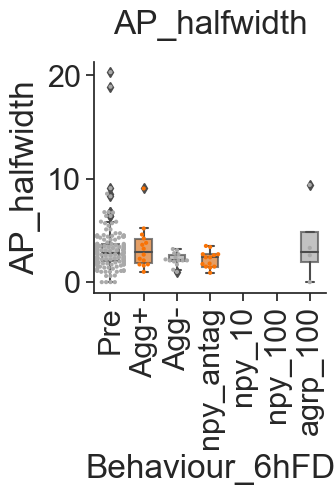

AP_time_to_peak noFD_Agg+ 0.1410590813350076
AP_time_to_peak Agg+_Agg- 0.20582824559459312
AP_time_to_peak Agg+_npy-antag 0.24359324877321087


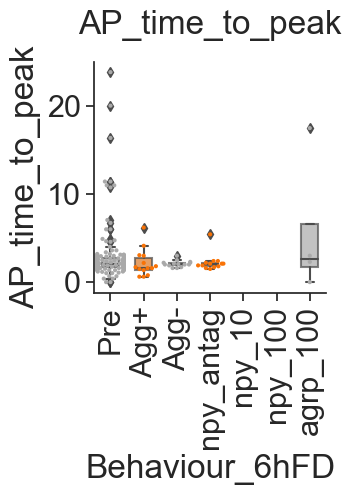

area(mV_ms) noFD_Agg+ 0.6589289916379197
area(mV_ms) Agg+_Agg- 0.3701980812474539
area(mV_ms) Agg+_npy-antag 0.34124913800172174


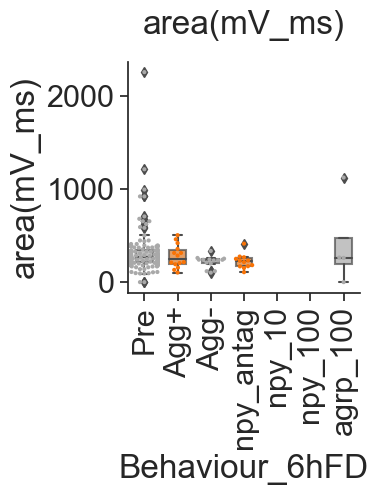

rheobase_at_-60mV_(pA) noFD_Agg+ 0.12814366123028542
rheobase_at_-60mV_(pA) Agg+_Agg- 0.8695672027305821
rheobase_at_-60mV_(pA) Agg+_npy-antag 0.7762368827794424


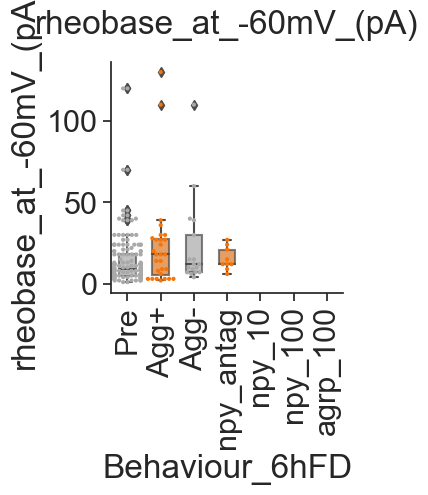

AHP_(mV) noFD_Agg+ 0.8046015121028867
AHP_(mV) Agg+_Agg- 1.0
AHP_(mV) Agg+_npy-antag 0.7522964425151529


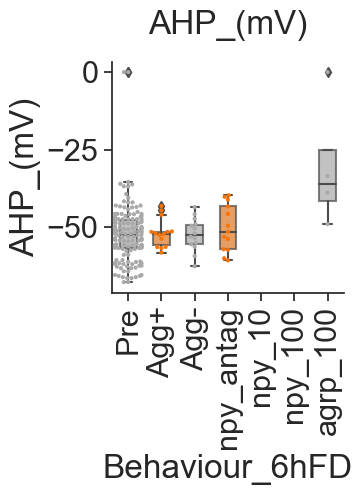

Vm noFD_Agg+ 0.567069169857365
Vm Agg+_Agg- 0.5768086443196911
Vm Agg+_npy-antag 0.0856036718206703


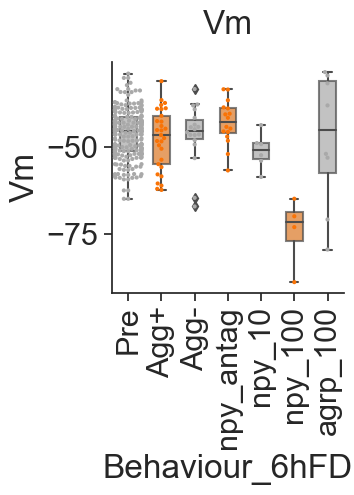

Input_Resistance noFD_Agg+ 0.005607881939624394
Input_Resistance Agg+_Agg- 0.00817812097305373
Input_Resistance Agg+_npy-antag 0.17784325470182227


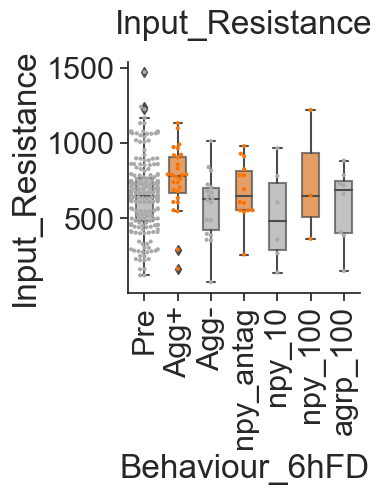

sPSC_frequency noFD_Agg+ 0.7025731164511213
sPSC_frequency Agg+_Agg- 0.8396693774680227
sPSC_frequency Agg+_npy-antag 0.283958429147953


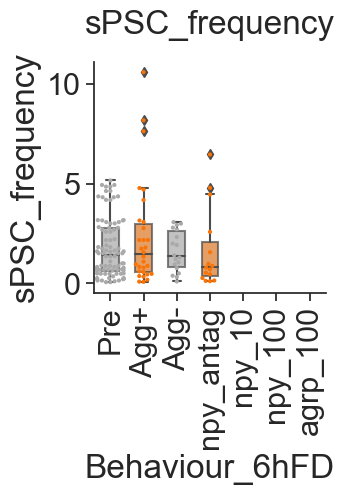

sPSC_Amplitude(pA) noFD_Agg+ 0.9107189625813171
sPSC_Amplitude(pA) Agg+_Agg- 0.02902227853608545
sPSC_Amplitude(pA) Agg+_npy-antag 0.129263740525376


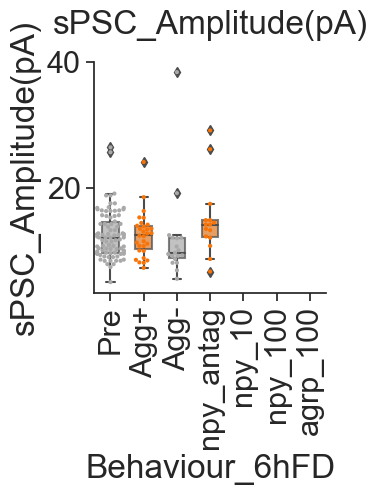

sPSCs_Rise time noFD_Agg+ 0.1751566179209043
sPSCs_Rise time Agg+_Agg- 0.0687656930735173
sPSCs_Rise time Agg+_npy-antag 7.801188013346792e-05


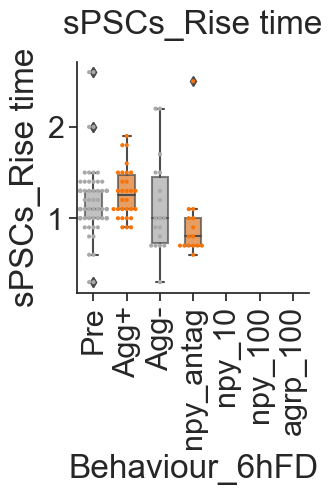

sPSCs (decay) noFD_Agg+ 0.7994251156426382
sPSCs (decay) Agg+_Agg- 0.5065305918475829
sPSCs (decay) Agg+_npy-antag 0.24287949638427397


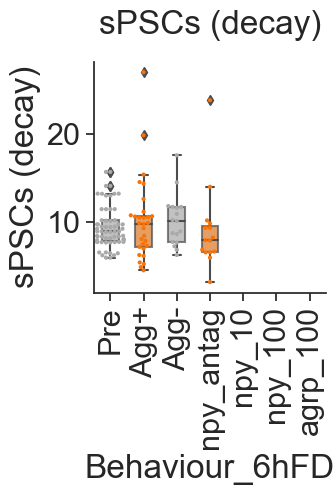

In [95]:
preprocess_plot(ephys, 'pan')


In [42]:
preprocess_plot(gal,'gal')

Cm(pF) noFD_Agg+ 0.568000349055369
Firing_freq_(Hz)_I0 noFD_Agg+ 0.28721546260366726
Instant_freq_(Hz) noFD_Agg+ 0.2541927698038654
isi_(ms) noFD_Agg+ 0.3025210084033614
CaT noFD_Agg+ 0.09172696328617409
Ih_at_-120mV noFD_Agg+ 0.34655777807143007
AP_ampl noFD_Agg+ 0.27062944050876925
AP_halfwidth noFD_Agg+ 0.7563025210084033
AP_time_to_peak noFD_Agg+ 0.1411764705882353
area(mV_ms) noFD_Agg+ 0.3697478991596639
rheobase_at_-60mV_(pA) noFD_Agg+ 0.12860985215882415
AHP_(mV) noFD_Agg+ 0.27226890756302524
Vm noFD_Agg+ 0.568000349055369
Input_Resistance noFD_Agg+ 0.9560979765177156
sPSC_frequency noFD_Agg+ 0.07868653086044392
sPSC_Amplitude(pA) noFD_Agg+ 0.8010337488598358


In [43]:
preprocess_plot(no_gal,'gal_minus')

Cm(pF) noFD_Agg+ 0.4312064746847355
Firing_freq_(Hz)_I0 noFD_Agg+ 0.4034858988262905
Instant_freq_(Hz) noFD_Agg+ 0.4034858988262905
isi_(ms) noFD_Agg+ 0.13333333333333333
CaT noFD_Agg+ 0.18249580310381686
Ih_at_-120mV noFD_Agg+ 0.9339723158912411
AP_ampl noFD_Agg+ 0.5333333333333333
AP_halfwidth noFD_Agg+ 0.2971897434333751
AP_time_to_peak noFD_Agg+ 0.26666666666666666
area(mV_ms) noFD_Agg+ 0.4
rheobase_at_-60mV_(pA) noFD_Agg+ 0.5152684554887583
AHP_(mV) noFD_Agg+ 1.0
Vm noFD_Agg+ 0.08112177677395067
Input_Resistance noFD_Agg+ 0.9068322981366461
sPSC_frequency noFD_Agg+ 0.9700734048560136
sPSC_Amplitude(pA) noFD_Agg+ 0.8161651409276747
sPSCs_Rise time noFD_Agg+ 0.7224445223795837
sPSCs (decay) noFD_Agg+ 1.0


Cm(pF) 0.7323693239926063


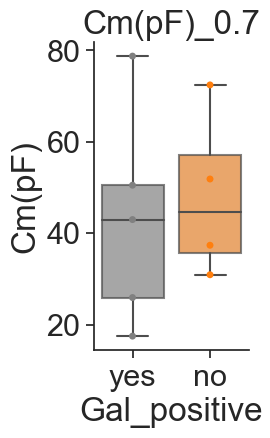

Firing_freq_(Hz)_I0 0.6407646405225094


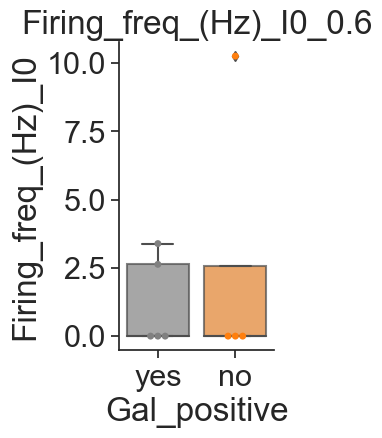

Instant_freq_(Hz) 0.6729139443059836


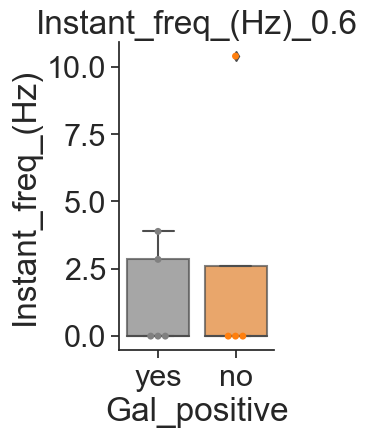

isi_(ms) 0.264690461240659


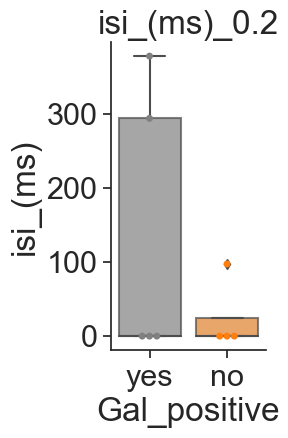

CaT 0.3112911367063223


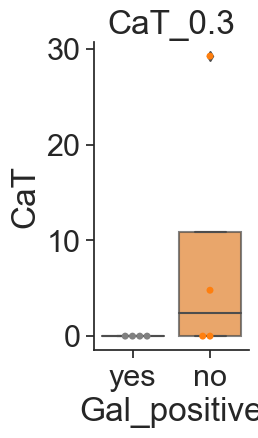

Ih_at_-120mV 0.8027274535869496


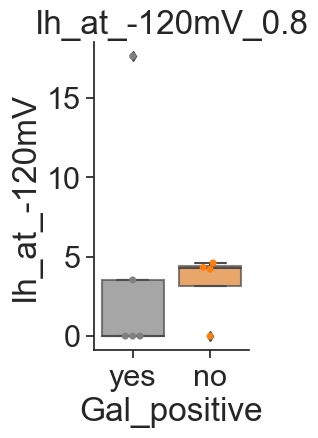

AP_ampl 0.8859255231987084


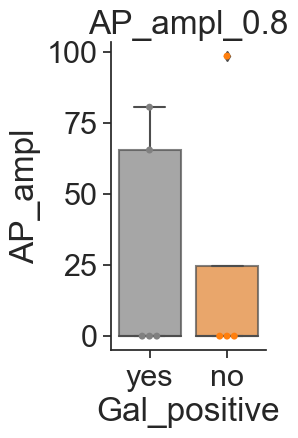

AP_halfwidth 0.32548590700011526


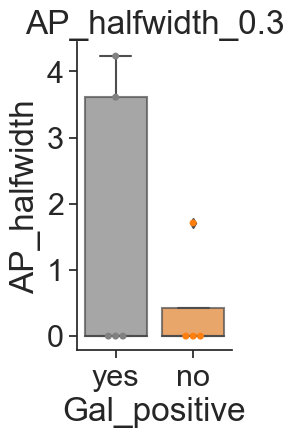

AP_time_to_peak 0.2899382771639767


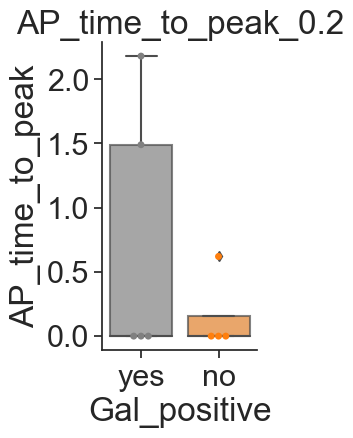

area(mV_ms) 0.37498685458791303


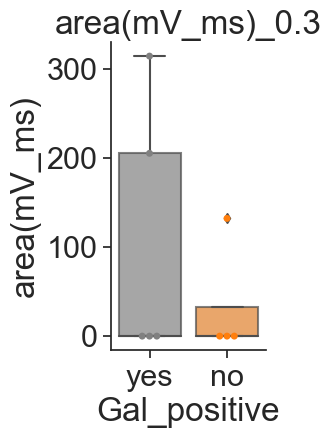

rheobase_at_-60mV_(pA) 0.4161053280322605


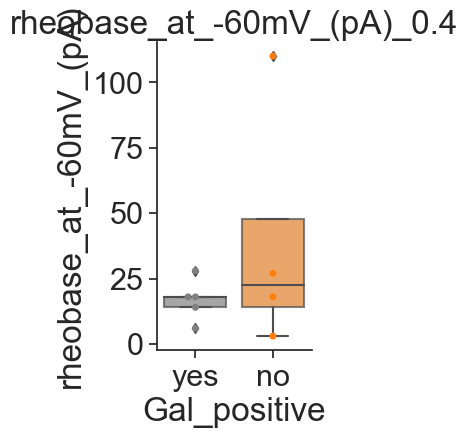

AHP_(mV) 0.80731274924489


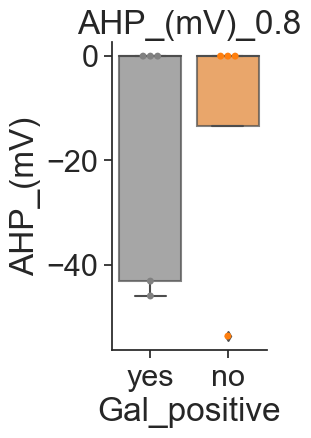

Vm 0.029015379302906888


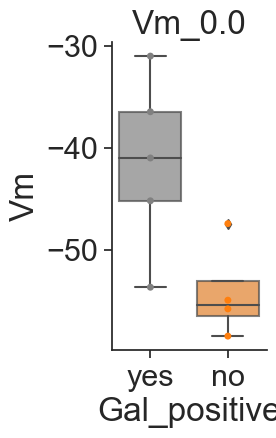

Input_Resistance 0.5478892229399508


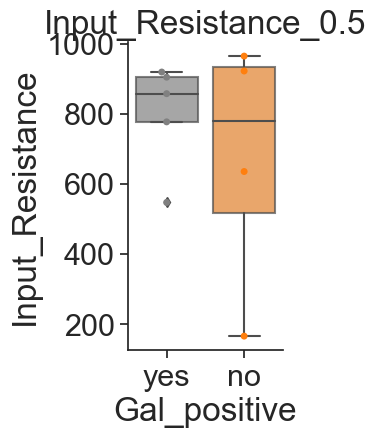

sPSC_frequency 0.2622481192712615


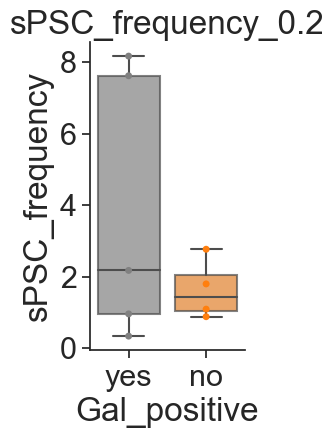

sPSC_Amplitude(pA) 0.8336416545013177


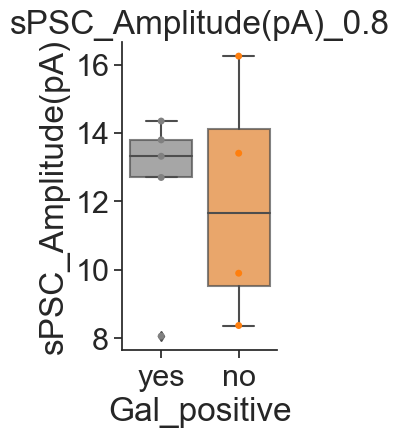

sPSCs_Rise time 0.1506195618276333


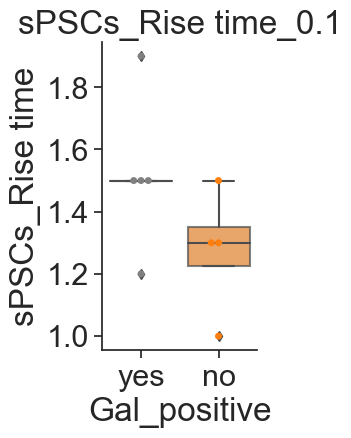

sPSCs (decay) 0.1946103198988765


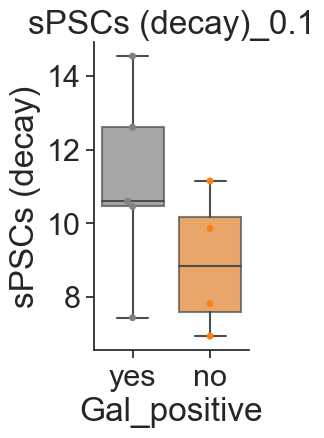

AC-I0 nan
AC_-60 nan


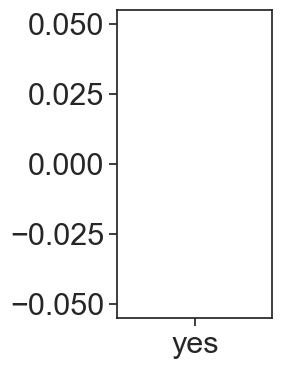

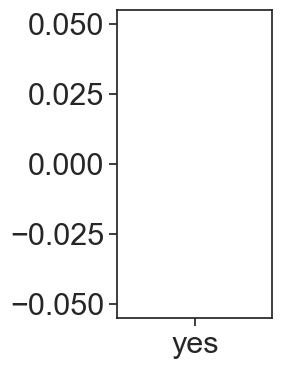

In [64]:
gals = pd.concat([gal,no_gal], axis = 0)
gals = gals[gals.Behaviour_6hFD.isin(['Agg+', 'Agg-'])]

ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
   'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    try:
        _, p = stats.ttest_ind(gals[(gals.Gal_positive == 'yes')][column].dropna(),
                                    gals[(gals.Gal_positive == 'no')][column].dropna(),
                                    equal_var = False)
        print(column , p)


        gals[column] = pd.to_numeric(gals[column])
        fig,ax = plt.subplots(figsize = (2,4))
        sns.swarmplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'])
        sns.boxplot(x='Gal_positive', y =column, data= gals, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
        sns.despine()
        plt.title(column + '_' + str(p)[:3])
        plt.savefig(f'output_figures/gal_nogal_{column}.png',dpi = 300, bbox_inches = 'tight')
        plt.show()
    except Exception:
        continue

In [65]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 'Firing_freq_(Hz)_I0': 'firing_freq'})
model = smf.ols('ih_current ~  I_zero_reclassified  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
I_zero_reclassified,75.862343,2.0,0.993219,0.371906
Residual,9127.445165,239.0,NaN,NaN


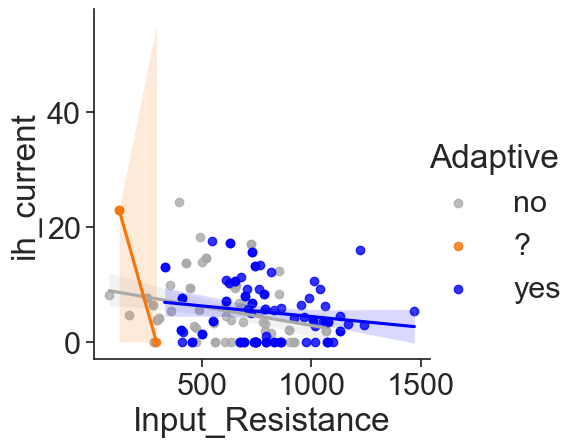

In [66]:
sns.lmplot(x = 'Input_Resistance', y = 'ih_current', data = trial, hue = 'Adaptive', palette = ['darkgray', '#F97306', 'blue'])
          


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


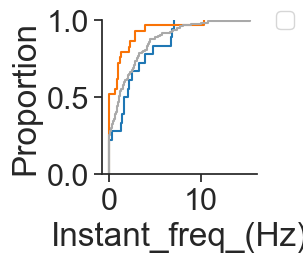

In [67]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']

fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

## silent prop

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Agg+                 6      15      8   29
Agg-                 2       4     12   18
Pre                 40      60    142  242
agrp_100             0       4      4    8
npy_10               0       5      1    6
npy_100              0       1      0    1
npy_antag            4       3      9   16
All                 52      92    176  320
0.006018435514743386


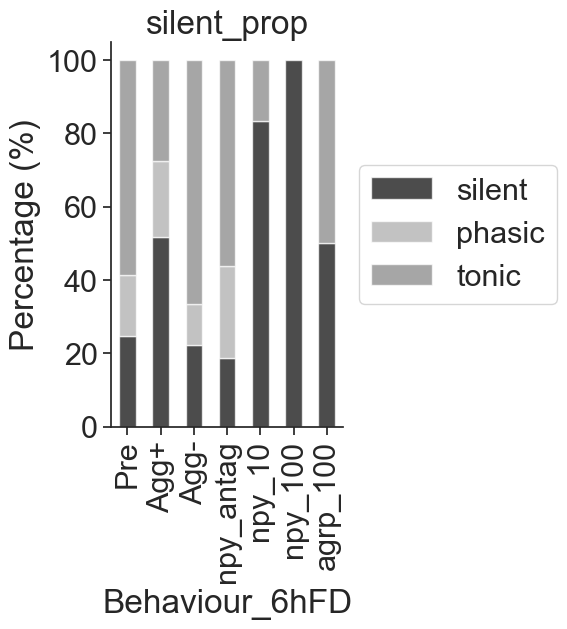

In [68]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_10','npy_100', 'agrp_100']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

I_zero        silent  tonic  All
Gal_positive                    
no                 3      1    4
yes                3      2    5
All                6      3    9
1.0


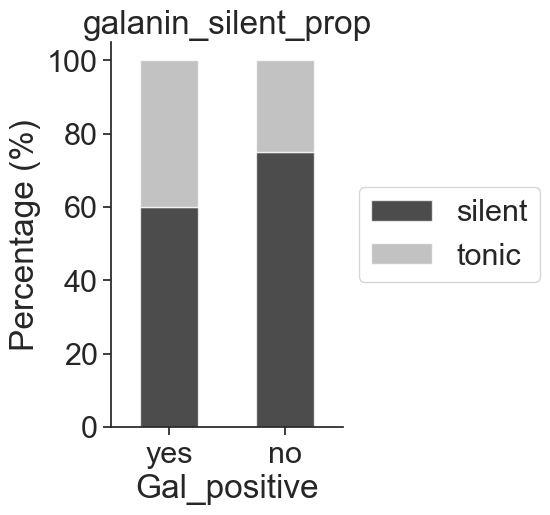

In [69]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

## adaptive prop

Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Agg+            1  12   16   29
Agg-            0  14    3   17
Pre             2  43   73  118
agrp_100        0   1    0    1
npy_antag       0   5    5   10
All             3  75   97  175
0.00959742719015299


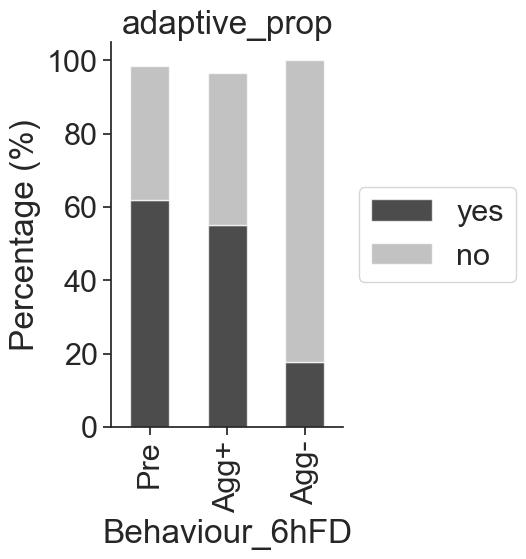

In [106]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy_10', 'agrp_100']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])

prop_plot(ad_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('adaptive_prop')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

Adaptive      no  yes  All
Gal_positive              
no             2    2    4
yes            3    2    5
All            5    4    9
1.0


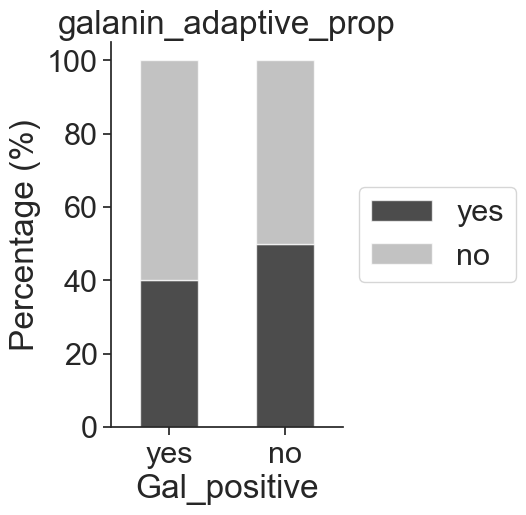

In [71]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## calcium T prop

cat_categ        no  yes  All
Behaviour_6hFD               
Agg+             20    8   28
Agg-              6   12   18
Pre             111   85  196
agrp_100          6    2    8
npy_antag        14    1   15
All             157  108  265
0.039288948290074614


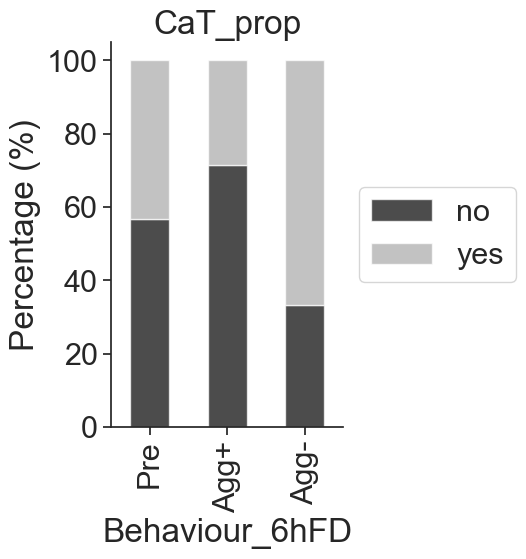

In [107]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

cat_categ     no  yes  All
Gal_positive              
no             2    2    4
yes            4    1    5
All            6    3    9
0.8125242693153686


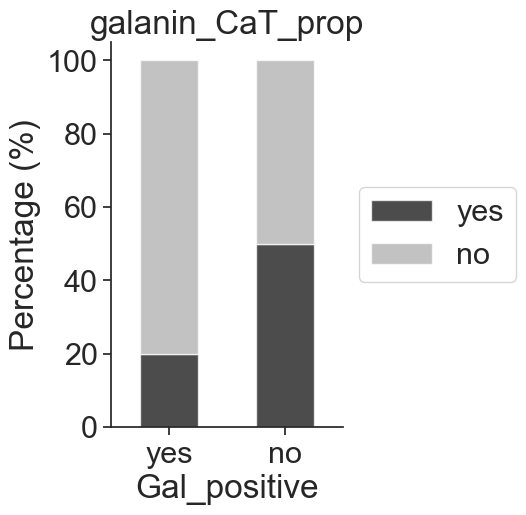

In [73]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

IH              no  yes  All
Behaviour_6hFD              
Pre             19   33   52
Agg+             5   10   15
Agg-             0    4    4
npy_antag        0    3    3
npy_10           0    4    4
agrp_100         1    3    4
0.32240274152832743


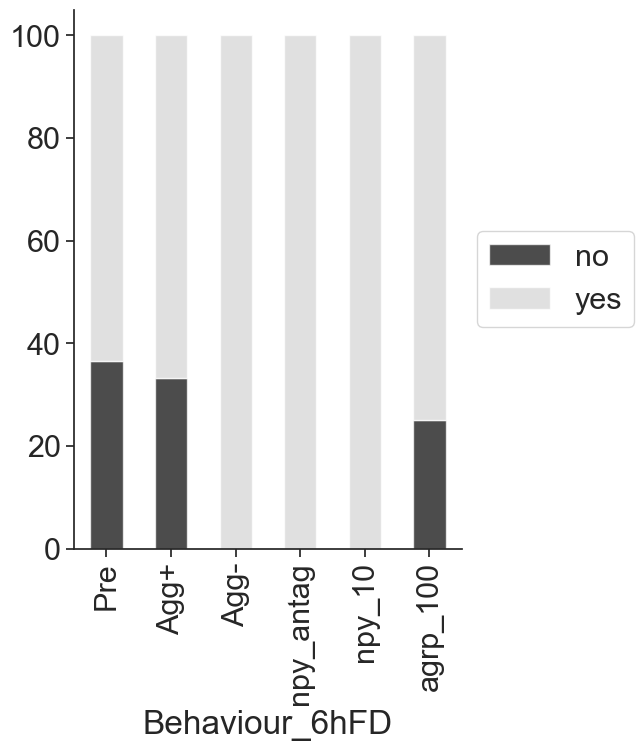

In [74]:
## prop of silent cells with/ without DB
DB_df = ephys[ephys.I_zero == 'silent']

DB_df.loc[(DB_df['Ih_at_-120mV'] == 0), 'IH']  = 'no'
DB_df.loc[(DB_df['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
DB_prop = pd.crosstab(DB_df['Behaviour_6hFD'], DB_df['IH'], margins = True).reset_index()
cols = ['Behaviour_6hFD', 'no', 'yes','All']
DB_prop = DB_prop[cols]
DB_prop['Behaviour_6hFD'] = pd.Categorical(DB_prop['Behaviour_6hFD'], cat)
DB_prop = DB_prop.sort_values(by = ['Behaviour_6hFD']).dropna()

plot_df = DB_prop.copy()

## chi square test
DB_prop.index = DB_prop.Behaviour_6hFD
DB_prop.drop(columns = ['Behaviour_6hFD'], inplace = True)
c, p, dof, expected = stats.chi2_contingency(DB_prop.iloc[:,:-1]) 
print(DB_prop)
print(p)

## plotting
plot_df.iloc[:, 1:5] = plot_df.iloc[:, 1:5].div(plot_df.All, axis = 0) *100
plot_df = plot_df.iloc[:, :-1]
plot_df.plot(
          x = 'Behaviour_6hFD', 
          kind = 'bar', 
          stacked = True,  
          mark_right = False,
          color = ['black','lightgray'],
          figsize = (5,7), alpha = 0.7)

ax = plt.gca()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.ylabel('percentage of neurons with Calium T')

## IH prop

IH              no  yes  All
Behaviour_6hFD              
Agg+            11   17   28
Agg-             1   17   18
Pre             54  142  196
agrp_100         1    7    8
npy_10           0    5    5
npy_100          2    1    3
npy_antag        3   12   15
All             72  201  273
0.06269604165915647


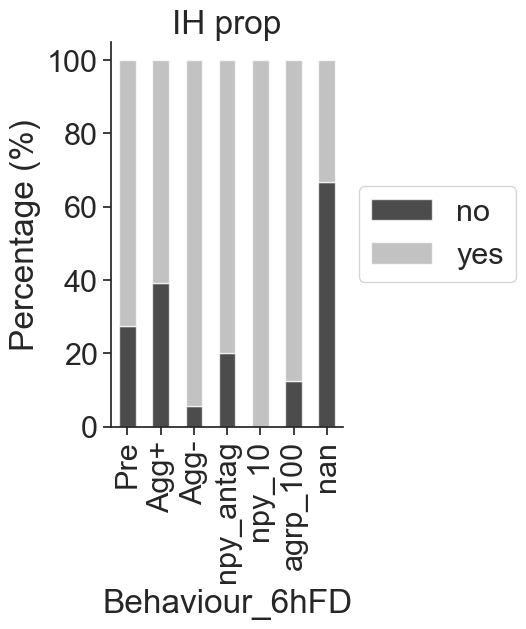

In [75]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic                9   36   45
silent               25   58   83
tonic                36  107  143
All                  70  201  271
0.44310456079543625


Text(0.5, 0, '')

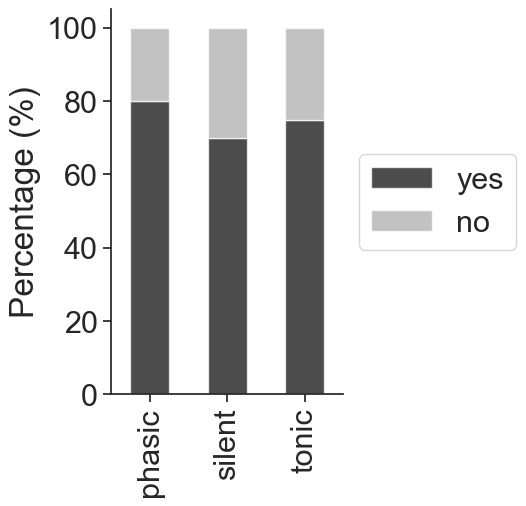

In [76]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# ramp analysis

In [89]:
df = pd.read_csv('ramps_all.csv')
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)', 
                        'experiment_day':'filename'}, inplace =True)

df.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
df = pd.merge(df, ephys, on = 'filename')

df['Injected'] = pd.Categorical(df['Injected'], df['Injected'].unique()[:-2]).as_ordered()

start = df['Ramp_start'][0]
num_spike = df.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')
df = df.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

df.loc[df['Event start '] == 0,'Event start '] = 2080
df['latency'] = df['Event start ']- start
df['num_spike'] = num_spike.num_spike
df =  pd.merge(df, ephys, on = ['filename', 'Behaviour_6hFD'])



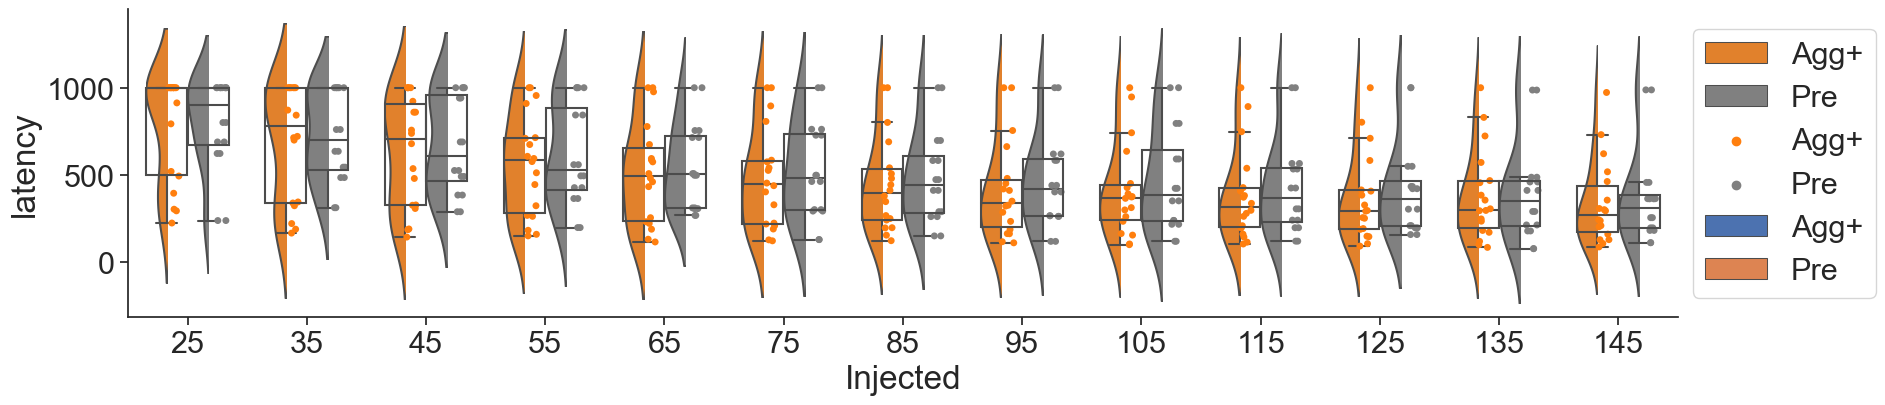

In [90]:
prop = 'latency'

fig = plt.subplots(figsize = [20,4])

palette = ['Tab:orange', 'gray']
ax = sns.violinplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', 
                    dodge = True, data = df,
                    palette=palette,width = 0.7,
                    scale="width", inner=None)

# ax = sns.lmplot(x ='Injected', y = prop, hue = 'Behaviour_6hFD', data = df)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

old_len_collections = len(ax.collections)
sns.stripplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
               dodge = True, data = df, palette=palette, ax=ax)

sns.boxplot(x  = 'Injected', y = prop, hue = 'Behaviour_6hFD',
                data = df, saturation=1, showfliers=False,
            width=0.7, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)


for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([.08, 0]))
    
ax.set_xlim(xlim)
ax.set_ylim(ylim)

sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [91]:
model = smf.ols('latency ~ C(Injected) * C(Behaviour_6hFD)', data=df).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Injected),7.381683e+06,12.0,8.054835,1.237526e-13
C(Behaviour_6hFD),1.470714e+05,1.0,1.925798,1.659617e-01
C(Injected):C(Behaviour_6hFD),1.909296e+04,12.0,0.020834,1.000000e+00
Residual,3.176953e+07,416.0,NaN,NaN


In [36]:
df['combination'] = df.Injected.astype(str) + " / " + df.Behaviour_6hFD
m_comp = pairwise_tukeyhsd(endog=df['latency'], groups=df['combination'], alpha=0.05)
m_comp._results_table

group1,group2,meandiff,p-adj,lower,upper,reject
105 / Agg+,105 / no_FD,53.6741,1.0,-402.1284,509.4766,False
105 / Agg+,115 / Agg+,-24.5592,1.0,-389.2012,340.0828,False
105 / Agg+,115 / no_FD,10.2366,1.0,-445.5659,466.0391,False
105 / Agg+,125 / Agg+,-40.0064,1.0,-404.6483,324.6356,False
105 / Agg+,125 / no_FD,-4.3258,1.0,-460.1283,451.4766,False
105 / Agg+,135 / Agg+,-25.7058,1.0,-390.3478,338.9361,False
105 / Agg+,135 / no_FD,-25.2135,1.0,-481.016,430.5889,False
105 / Agg+,145 / Agg+,-68.4944,1.0,-433.1364,296.1476,False
105 / Agg+,145 / no_FD,-48.6384,1.0,-504.4409,407.1641,False
105 / Agg+,25 / Agg+,359.0997,0.0598,-5.5423,723.7417,False


# estrous cycle influence

I_zero         phasic  silent  tonic  All
estrous_stage                            
?                   1       1      2    4
D                   7       9     26   42
E                   3       6      8   17
M                   1       3      6   10
P                   1       5      7   13
no VS               1       2      9   12
not taken           1       2      1    4
All                15      28     59  102
0.8946220452824961
I_zero          phasic  silent  tonic  All
estrous_stage                             
D                    2       5      3   10
E                    2       1      0    3
M                    0       6      3    9
P                    0       3      2    5
to be stained        2       4     12   18
All                  6      19     20   45
0.038356354409165745


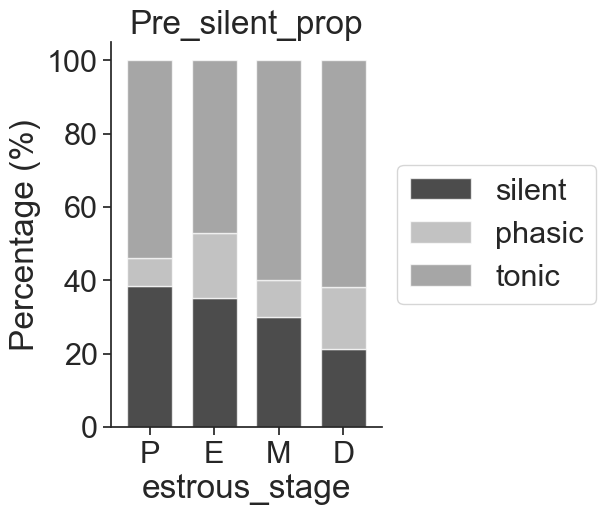

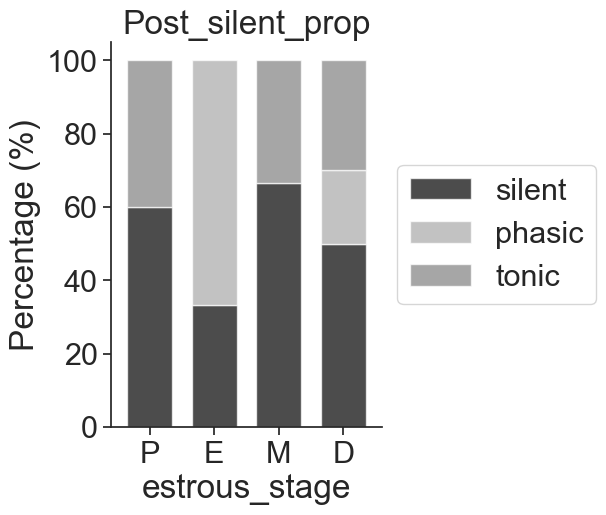

In [5]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

0.9832758677714625 0.016724132228537525


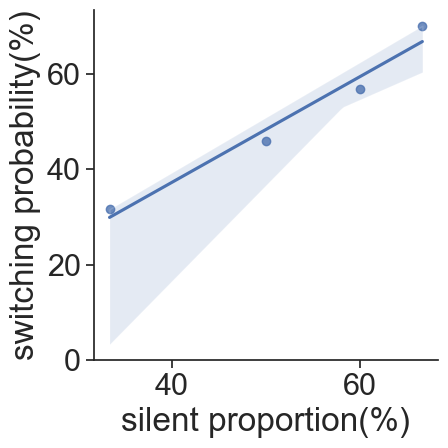

In [26]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

F_onewayResult(statistic=0.4328137741108785, pvalue=0.7300797086921997)


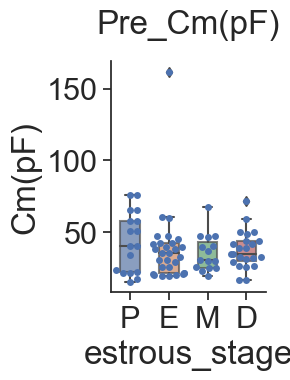

F_onewayResult(statistic=0.16419143036570535, pvalue=0.9203823289842754)


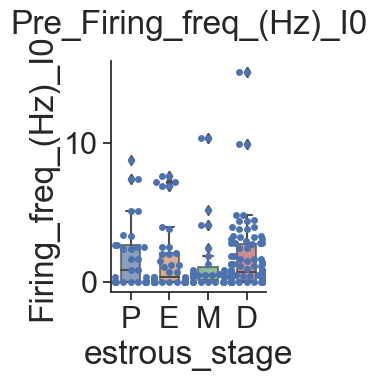

F_onewayResult(statistic=0.12925740334979846, pvalue=0.9426345590150569)


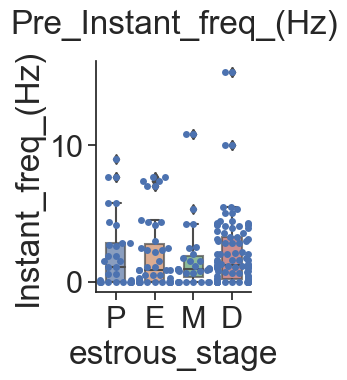

F_onewayResult(statistic=1.2774817893531523, pvalue=0.28329296020841255)


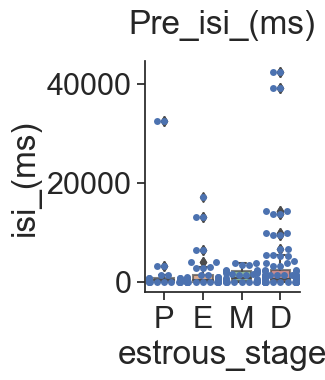

F_onewayResult(statistic=1.0513672946650927, pvalue=0.37130456278854557)


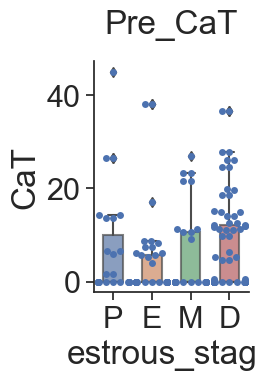

F_onewayResult(statistic=3.496561798954224, pvalue=0.016803282722984963)


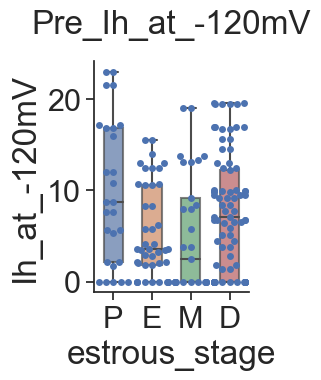

F_onewayResult(statistic=1.108879907974668, pvalue=0.3468291704323018)


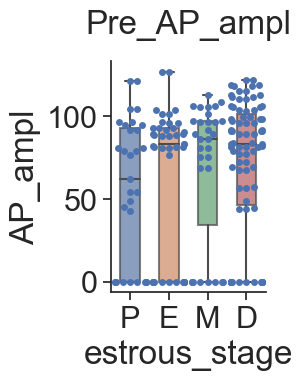

F_onewayResult(statistic=0.48869065638809406, pvalue=0.6905576403797412)


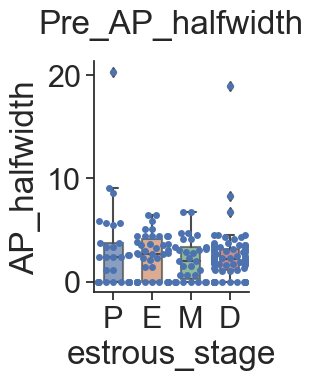

F_onewayResult(statistic=1.41581563601425, pvalue=0.23960995398410603)


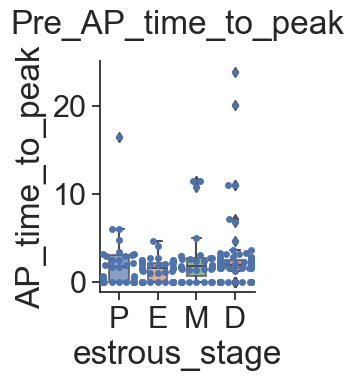

F_onewayResult(statistic=0.4114251423992339, pvalue=0.7449843408624836)


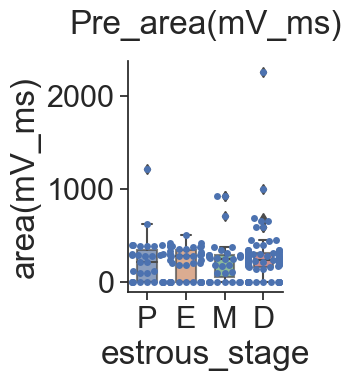

F_onewayResult(statistic=6.036369330877578, pvalue=0.00067723895268822)


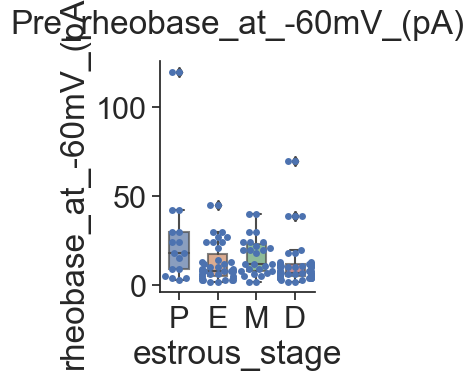

F_onewayResult(statistic=0.9158237373345464, pvalue=0.43441218449138197)


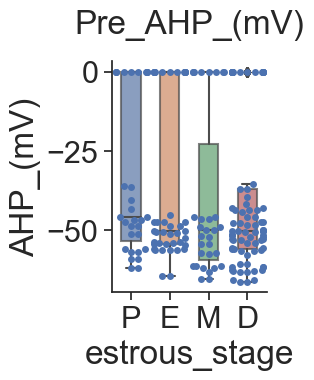

F_onewayResult(statistic=1.058407276515252, pvalue=0.36793188978376445)


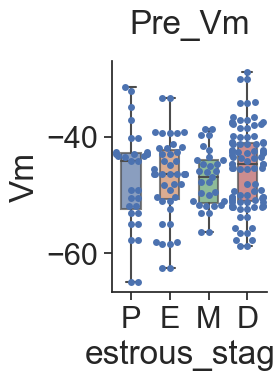

F_onewayResult(statistic=7.6427779774152125, pvalue=7.849442098541367e-05)


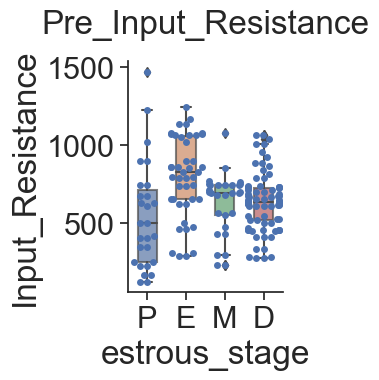

F_onewayResult(statistic=3.833178812773564, pvalue=0.012537389043004572)


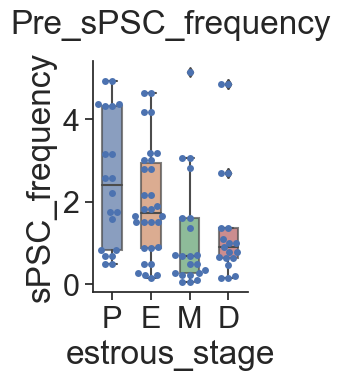

F_onewayResult(statistic=1.6849244486938435, pvalue=0.1762375930759221)


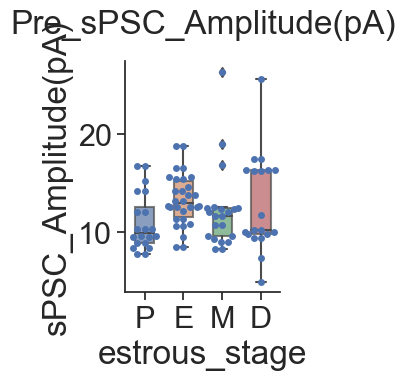

F_onewayResult(statistic=2.1523174228524526, pvalue=0.10304262675136372)


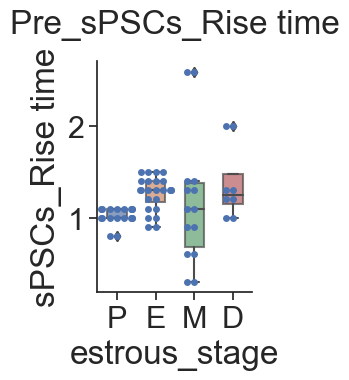

F_onewayResult(statistic=1.7096790630084824, pvalue=0.17500564556018017)


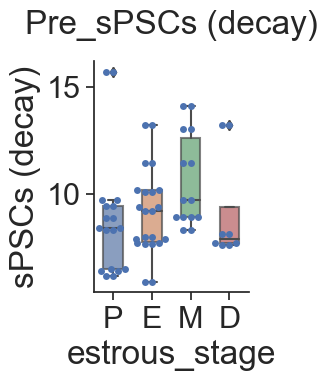

F_onewayResult(statistic=1.1688182850767281, pvalue=0.33363171282257625)
F_onewayResult(statistic=3.7208446444911565, pvalue=0.018871194740943308)


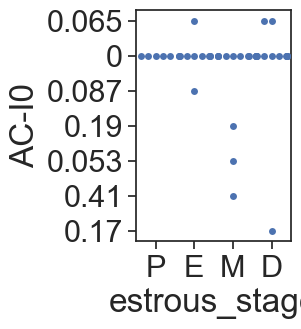

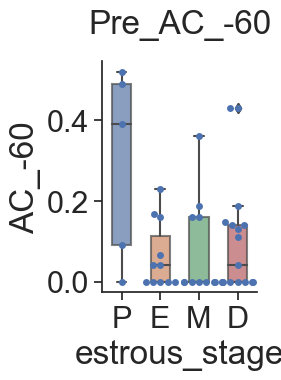

In [19]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for state in ['Pre']:
    for column in ls:
        state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        
        try:

            print(stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna()))
            


            fig,ax = plt.subplots(figsize = (2,3))
            sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 1)
            sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5)
            sns.despine()
            plt.title(f'{state}_{column}', pad = 20)
            
            plt.show()
        except Exception:
            continue

cat_categ      no  yes  All
estrous_stage              
?               1    3    4
D              18   17   35
E              12    5   17
M               6    3    9
P               6    5   11
not taken       2    2    4
All            45   35   80
0.576878693704074
cat_categ estrous_stage         no        yes
4                     P  54.545455  45.454545
2                     E  70.588235  29.411765
3                     M  66.666667  33.333333
1                     D  51.428571  48.571429


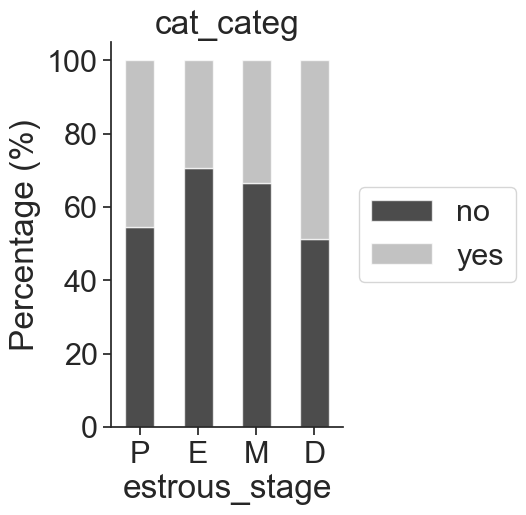

-0.14746222510761411 0.8525377748923859


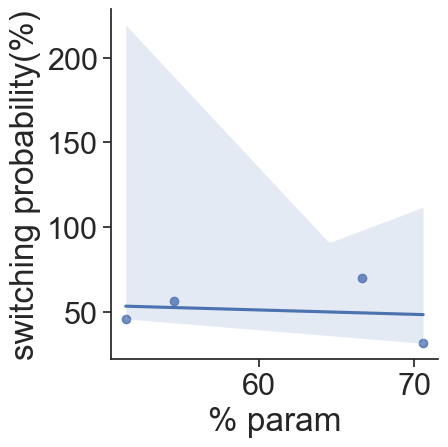

IH             no  yes  All
estrous_stage              
?               0    4    4
D               9   26   35
E               4   13   17
M               5    4    9
P               2    9   11
not taken       2    2    4
All            22   58   80
0.23946891370955553
IH estrous_stage         no        yes
4              P  18.181818  81.818182
2              E  23.529412  76.470588
3              M  55.555556  44.444444
1              D  25.714286  74.285714


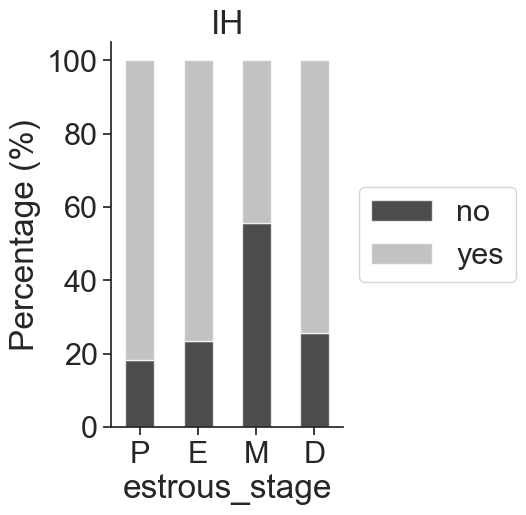

0.6875825971154546 0.31241740288454545


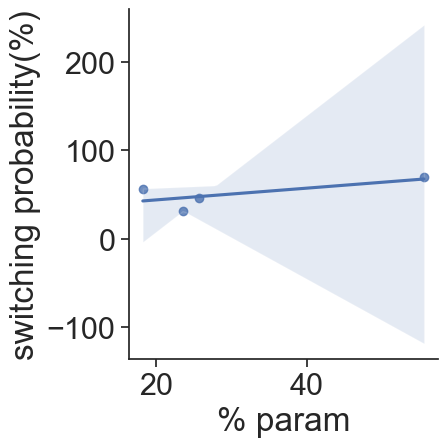

Adaptive       ?  no  yes  All
estrous_stage                 
?              0   0    1    1
D              0   7    9   16
E              0   2    9   11
M              0   5    4    9
P              1   2    3    6
All            1  16   26   43
0.24744548429889165
Adaptive estrous_stage         no        yes
4                    P  33.333333  50.000000
2                    E  18.181818  81.818182
3                    M  55.555556  44.444444
1                    D  43.750000  56.250000


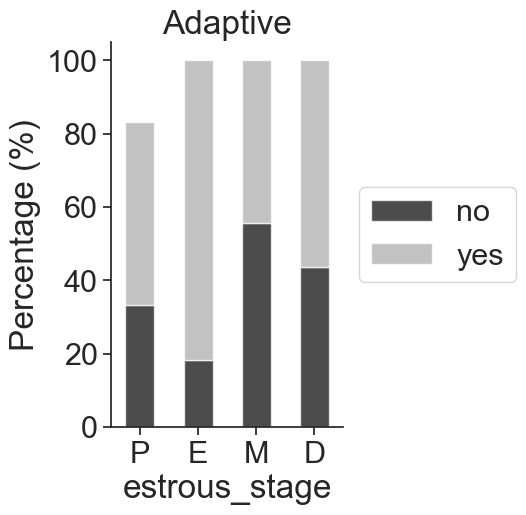

0.8550671743764791 0.14493282562352094


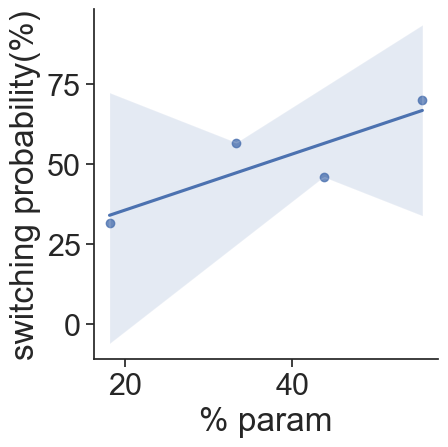

In [51]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr)
    plt.xlabel('% param')
    plt.ylabel('switching probability(%)')
    plt.show()

# npy administration

In [97]:
def pairline_plot(y, data):
    plt.subplots(figsize = (1.5,2))
    sns.lineplot(x = 'condition', y = y, hue = 'cell_id',data = data, palette = ['Tab:red'], alpha = 0.8)
    sns.swarmplot(x = 'condition', y = y ,data = data, palette = ['Tab:red'], alpha = 0.8)
    sns.boxplot(x = 'condition', y = y,data = data, palette = ['Tab:red'],boxprops=dict(alpha=.5), width = 0.5)
    ax = plt.gca()
    ax.get_legend().remove()
    sns.despine()
    plt.xticks(rotation = 90)
    plt.xlabel('')
    plt.show()

def sub_datset(data):

    vm = data.melt(id_vars=['cell_id'], value_vars=['Vm_control', 'Vm_drug'], var_name='condition', value_name='Vm')
    ir = data.melt(id_vars=['cell_id'], value_vars=['IR_control', 'IR_drug'], var_name='condition', value_name='IR')
    ih = data.melt(id_vars=['cell_id'], value_vars=['Ih_control', 'Ih_drug'], var_name='condition', value_name='Ih')
    fr = data.melt(id_vars=['cell_id'], value_vars=['firing_freq_control', 'firing_freq_drug'], var_name='condition', value_name='firing_freq')

    return [vm, ir, ih, fr]
    

100npy


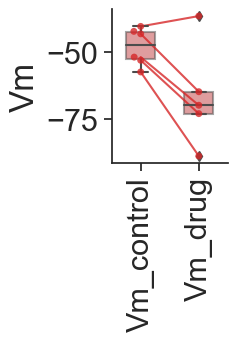

100npy


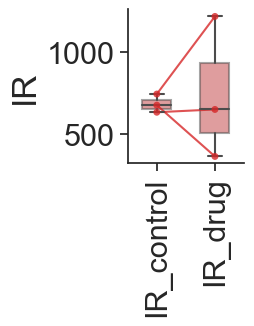

100npy


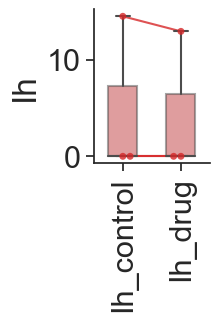

100npy


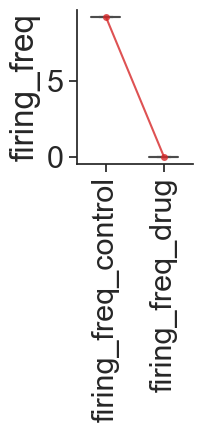

10npy


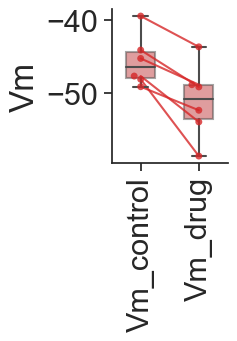

10npy


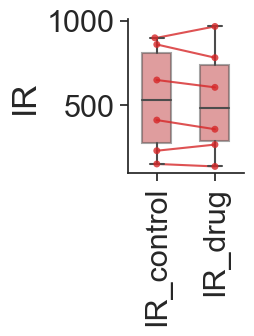

10npy


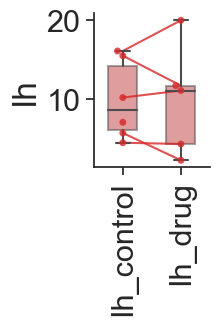

10npy


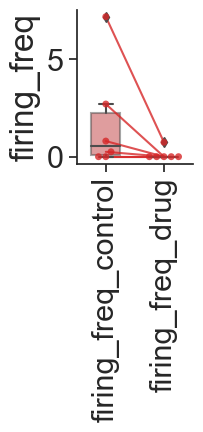

In [98]:
df = pd.read_csv('pharmacology.csv')
df['drug'] = df.conc_nM.astype(str) + df.identity


for drug in df.drug.unique()[:-1]:
    drug_df = df[df.drug == drug]
    df_list = sub_datset(drug_df)

    for subdata in df_list:
        
        subdata  = subdata.dropna()
        if len(subdata.condition.unique()) <2:
            continue
        else:
            print(drug)
            pairline_plot(str(subdata.columns[2]), subdata)